# Setup

In [1]:
# IMPORTS
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import sys
import os
import json
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Module imports
from prp.task_generator import generate_task_patterns, generate_fixed_task_set
from prp.nn_wrapper import TaskNetworkWrapper
from prp.prp_simulator import sweep_soa, run_prp_trial
from prp.training_utils import train_with_optional_multitask, train_with_control_config 
from prp.threshold_utils import optimize_lca_threshold, choose_onset_policy, optimize_reward_rate_threshold
from prp.task_generator   import generate_fixed_task_set
from prp.threshold_utils  import optimize_lca_threshold_dist
from prp.lca              import run_lca_avg
from prp.training_set import generate_training_set_matlab_style 

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [2]:
# Reload module when making live edits
import importlib
import prp.prp_simulator as prp_simulator
importlib.reload(prp_simulator)

<module 'prp.prp_simulator' from '/home/acesmeci/Code/prp_model/prp/prp_simulator.py'>

In [2]:
# New model loading cell

# Match exactly what you used in scripts/train_model.py:
wrapper = TaskNetworkWrapper(
    stim_input_dim = 3 * 3,    # N_pathways * N_features
    task_input_dim = 3 ** 2,   # N_pathways^2
    hidden_dim     = 100,
    output_dim     = 3 * 3,
    learning_rate  = 0.3,
    device         = "cpu"
)

# Now load
wrapper.model.load_state_dict(torch.load("../output/trained_models/trained_model_sim3_init01.pth"))
wrapper.model.eval()
print("✅ Loaded model, ready for inference.")



✅ Loaded model, ready for inference.


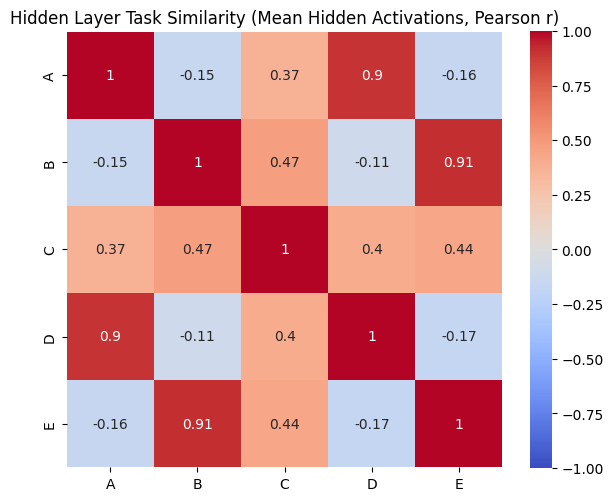

Pearson(A,D) = 0.9035555769972211
Pearson(B,E) = 0.9146682569973094
Pearson(A,B) = -0.15341980588109125


In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from prp.task_generator import generate_fixed_task_set  # produces A..E with meta["task_indices"]

@torch.no_grad()
def hidden_task_similarity_from_wrapper(wrapper, seed=42, reduce="mean"):
    """
    Computes hidden-layer task similarity from mean hidden activations per task.

    Procedure:
    1) Generate a fixed set of single-task patterns (A..E)
    2) Run forward pass to collect hidden activations
    3) Average hidden activations per task
    4) Compute Pearson correlation across tasks

    Returns:
        labels (list[str]): ['A','B','C','D','E']
        corr (np.ndarray): 5x5 Pearson correlation matrix
        hidden_means (dict): task_label -> mean hidden vector (H,)
    """

    # Generate deterministic single-task set
    inp, task_onehots, _, meta = generate_fixed_task_set(seed=seed)
    task_labels = ['A', 'B', 'C', 'D', 'E']

    # Collect mean hidden activations per task
    hidden_means = {}
    for lab in task_labels:
        mask = (meta["task_indices"] == lab)
        X = torch.tensor(inp[mask], dtype=torch.float32, device=wrapper.device)
        T = torch.tensor(task_onehots[mask], dtype=torch.float32, device=wrapper.device)

        # Forward pass -> hidden activations
        _, H = wrapper.model(X, T)  # H: (n_samples_for_task, hidden_dim)

        if reduce == "median":
            h_mean = H.median(dim=0).values
        else:
            h_mean = H.mean(dim=0)

        hidden_means[lab] = h_mean.detach().cpu().numpy()

    # Stack and compute Pearson correlation across tasks
    A = np.stack([hidden_means[lab] for lab in task_labels], axis=0)  # (5, H)
    corr = np.corrcoef(A)

    return task_labels, corr, hidden_means


# ---- Run and plot ----
labels, corr_matrix, hidden_means = hidden_task_similarity_from_wrapper(wrapper, seed=42, reduce="mean")

df = pd.DataFrame(corr_matrix, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Hidden Layer Task Similarity (Mean Hidden Activations, Pearson r)")
plt.tight_layout()
plt.show()

# Print key pairs
print("Pearson(A,D) =", df.loc["A","D"])
print("Pearson(B,E) =", df.loc["B","E"])
print("Pearson(A,B) =", df.loc["A","B"])


### New training (MATLAB-style)

In [ ]:
# 27 Fixed, noise-free training set experiment

# 1) Build exhaustive, noise-free, same across tasks
X, T, Y, _ = generate_training_set_matlab_style()

# 2) Train
wrapper = TaskNetworkWrapper(
    stim_input_dim=9, task_input_dim=9, hidden_dim=100, output_dim=9,
    learning_rate=0.3, device="cpu"
)
wrapper.train_online(
    torch.tensor(X), torch.tensor(T), torch.tensor(Y),
    max_epochs=3000, stop_loss=1e-3, print_every=50
)

torch.save(wrapper.model.state_dict(), "../output/trained_models/trained_model_init01_all.pth")
print("✅ Model saved to output/trained_model_init005.pth")

# 3) Check Pearson AD/BE on task→hidden (same code you already have)
# Expectation: AD/BE should jump noticeably vs. the random/noisy regime.


Epoch 0000 | Loss: 0.0984 | Acc: 0.096
Epoch 0050 | Loss: 0.0748 | Acc: 0.578
Epoch 0100 | Loss: 0.0528 | Acc: 0.659
Epoch 0150 | Loss: 0.0426 | Acc: 0.681
Epoch 0200 | Loss: 0.0347 | Acc: 0.778
Epoch 0250 | Loss: 0.0304 | Acc: 0.948
Epoch 0300 | Loss: 0.0209 | Acc: 1.000
Epoch 0350 | Loss: 0.0105 | Acc: 1.000
Epoch 0400 | Loss: 0.0055 | Acc: 1.000
Epoch 0450 | Loss: 0.0034 | Acc: 1.000
Epoch 0500 | Loss: 0.0024 | Acc: 1.000
Epoch 0550 | Loss: 0.0019 | Acc: 1.000
Epoch 0600 | Loss: 0.0015 | Acc: 1.000
Epoch 0650 | Loss: 0.0013 | Acc: 1.000
Epoch 0700 | Loss: 0.0011 | Acc: 1.000
✅ Converged at epoch 0731 | Loss: 0.0010
✅ Model saved to output/trained_model_init005.pth


### Training Diagnostics
**Why did the task similarities jumped from ~0.35 to ~0.90**

In [20]:
import numpy as np, torch, pandas as pd

def set_seeds(seed=0):
    np.random.seed(seed)
    torch.manual_seed(seed)

TASK_MAP = {'A': (0,0), 'B': (1,1), 'C': (2,2), 'D': (0,1), 'E': (1,0)}
def task_to_col(name, N=3):
    i_in, i_out = TASK_MAP[name]
    return i_in * N + i_out

def cosine(a,b):
    return float(np.dot(a,b) / ((np.linalg.norm(a)+1e-8)*(np.linalg.norm(b)+1e-8)))

def weight_sims(wrapper):
    W = wrapper.model.fc_task_hidden.weight.detach().cpu().numpy()  # (H, 9)
    A,B,D,E = [task_to_col(x) for x in ["A","B","D","E"]]
    return {
        "wcos_AD": cosine(W[:,A], W[:,D]),
        "wcos_BE": cosine(W[:,B], W[:,E]),
        "wcos_AB": cosine(W[:,A], W[:,B]),
    }

def activation_sims(wrapper, X, T):
    means, S = wrapper.model.task_similarity_hidden(torch.tensor(X), torch.tensor(T),
                                                    metric="pearson", reduce="mean")
    A,B,D,E = [task_to_col(x) for x in ["A","B","D","E"]]
    return {
        "pear_AD": float(S[A,D]),
        "pear_BE": float(S[B,E]),
        "pear_AB": float(S[A,B]),
    }

def init_report(wrapper):
    def mm(w):
        w = w.detach().cpu().numpy()
        return float(w.min()), float(w.max())
    return {
        "IH_minmax": mm(wrapper.model.fc_input_hidden.weight),
        "TH_minmax": mm(wrapper.model.fc_task_hidden.weight),
        "HO_minmax": mm(wrapper.model.fc_hidden_output.weight),
        "TO_minmax": mm(wrapper.model.fc_task_output.weight),
        "bias": float(wrapper.model.bias_offset),
    }


In [21]:
from prp.nn_wrapper import TaskNetworkWrapper
from prp.training_set import generate_training_set_matlab_style

def train_with_wrapper(wrapper, X, T, Y, max_epochs=3000, stop_loss=1e-3, print_every=0, emulate_old=False):
    wrapper.model.train()
    stim = torch.tensor(X).to(wrapper.device)
    task = torch.tensor(T).to(wrapper.device)
    y_true = torch.tensor(Y).to(wrapper.device)

    if not emulate_old:
        stim = stim.float(); task = task.float(); y_true = y_true.float()

    N = stim.size(0)
    for epoch in range(max_epochs):
        total_loss = 0.0
        correct = 0

        # old: randperm on CPU; new: randperm on device
        if emulate_old:
            perm = torch.randperm(N)  # CPU
        else:
            perm = torch.randperm(N, device=wrapper.device)

        for i in perm:
            if emulate_old:
                i = int(i.item())
            x_i = stim[i:i+1]
            t_i = task[i:i+1]
            y_i = y_true[i:i+1]

            if emulate_old:
                wrapper.optimizer.zero_grad()
            else:
                wrapper.optimizer.zero_grad(set_to_none=True)

            y_pred, _ = wrapper.model(x_i, t_i)
            loss = wrapper.loss_fn(y_pred, y_i)
            loss.backward()
            wrapper.optimizer.step()

            total_loss += float(loss)
            correct += int((y_pred.argmax(dim=1) == y_i.argmax(dim=1)).sum())

        avg_loss = total_loss / N
        acc = correct / N

        if print_every and (epoch % print_every == 0):
            print(epoch, avg_loss, acc)

        if avg_loss <= stop_loss:
            break

    return avg_loss, acc


In [22]:
def run_condition(tag, seed, init_scale=0.1, init_task_scale=None, bias_offset=-2.0, emulate_old_wrapper=False):
    set_seeds(seed)
    X, T, Y, meta = generate_training_set_matlab_style()  # constant dataset :contentReference[oaicite:2]{index=2}

    wrapper = TaskNetworkWrapper(
        stim_input_dim=9, task_input_dim=9, hidden_dim=100, output_dim=9,
        learning_rate=0.3, device="cpu",
        init_scale=init_scale,
        init_task_scale=init_task_scale,
        bias_offset=bias_offset,
        default_weight_decay=0.0,
    )

    init_info = init_report(wrapper)
    final_loss, final_acc = train_with_wrapper(wrapper, X, T, Y, emulate_old=emulate_old_wrapper)

    out = {"tag": tag, "seed": seed, "final_loss": final_loss, "final_acc": final_acc}
    out |= init_info
    out |= weight_sims(wrapper)
    out |= activation_sims(wrapper, X, T)
    return out


In [23]:
rows = []
seeds = [0,1,2,3,4]  # 5 reps is enough to see a systematic effect

# C0: new defaults (whatever your wrapper+network currently do)
for s in seeds:
    rows.append(run_condition("C0_new_default", s, init_scale=0.1, init_task_scale=None, bias_offset=-2.0, emulate_old_wrapper=False))

# C1: force init_task_scale=0.1 explicitly (rules out accidental scaling differences)
for s in seeds:
    rows.append(run_condition("C1_force_taskscale_0.1", s, init_scale=0.1, init_task_scale=0.1, bias_offset=-2.0, emulate_old_wrapper=False))

# C2: emulate old wrapper training behavior (dtype/zero_grad/perm)
for s in seeds:
    rows.append(run_condition("C2_oldwrapper_emulation", s, init_scale=0.1, init_task_scale=0.1, bias_offset=-2.0, emulate_old_wrapper=True))

df = pd.DataFrame(rows)
df[["tag","seed","TH_minmax","wcos_AD","wcos_BE","pear_AD","pear_BE","final_loss","final_acc"]]


/tmp/ipykernel_203311/2546444838.py:41: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
/home/acesmeci/code/prp_model/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/acesmeci/code/prp_model/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,tag,seed,TH_minmax,wcos_AD,wcos_BE,pear_AD,pear_BE,final_loss,final_acc
0,C0_new_default,0,"(-0.09997029602527618, 0.09981658309698105)",0.947790,0.935856,0.952655,0.934945,0.001000,1.0
1,C0_new_default,1,"(-0.09980262815952301, 0.09997143596410751)",0.944434,0.943132,0.933162,0.927364,0.000999,1.0
2,C0_new_default,2,"(-0.09987697750329971, 0.09961525350809097)",0.926114,0.946792,0.911340,0.952154,0.000999,1.0
3,C0_new_default,3,"(-0.09998174011707306, 0.09982778131961823)",0.913208,0.928990,0.897610,0.912208,0.000998,1.0
4,C0_new_default,4,"(-0.09963414818048477, 0.09945064783096313)",0.941806,0.955607,0.932092,0.963520,0.000998,1.0
5,C1_force_taskscale_0.1,0,"(-0.09997029602527618, 0.09981658309698105)",0.947790,0.935856,0.952655,0.934945,0.001000,1.0
6,C1_force_taskscale_0.1,1,"(-0.09980262815952301, 0.09997143596410751)",0.944434,0.943132,0.933162,0.927364,0.000999,1.0
7,C1_force_taskscale_0.1,2,"(-0.09987697750329971, 0.09961525350809097)",0.926114,0.946792,0.911340,0.952154,0.000999,1.0
8,C1_force_taskscale_0.1,3,"(-0.09998174011707306, 0.09982778131961823)",0.913208,0.928990,0.897610,0.912208,0.000998,1.0
9,C1_force_taskscale_0.1,4,"(-0.09963414818048477, 0.09945064783096313)",0.941806,0.955607,0.932092,0.963520,0.000998,1.0


### Init-fixed training

In [7]:
# Construct the wrapper
wrapper = TaskNetworkWrapper(
    stim_input_dim = 3*3,
    task_input_dim = 3**2,
    hidden_dim     = 100,
    output_dim     = 3*3,
    learning_rate  = 0.3,
    # Sim-3 init/bias/decay:
    init_scale=0.1,
    init_task_scale=None,   # → 0.1, same as MATLAB for Sim-3
    bias_offset=-2.0,
    default_weight_decay=0.0,  # Sim-3 uses no L2
    device="cpu",
)
print("✅ Model constructed.")

# Now load
init = "sim3_init01"
wrapper.model.load_state_dict(torch.load(f"../output/trained_models/trained_model_{init}.pth"))
wrapper.model.eval()
print(f"✅ Loaded model {init}, ready for inference.")

✅ Model constructed.
✅ Loaded model sim3_init01, ready for inference.


In [3]:
# LOOK INTO WHY bias=False
wrapper.model.eval()

TaskNetwork(
  (fc_input_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_task_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_hidden_output): Linear(in_features=100, out_features=9, bias=False)
  (fc_task_output): Linear(in_features=9, out_features=9, bias=False)
  (act): Sigmoid()
)

In [ ]:
# Generate training set & train

# 1) Exhaustive, noise-free, same across tasks (A,B,D,E,C)
X, T, Y, _ = generate_training_set_matlab_style()

# 2) Train
wrapper.train_online(
    torch.tensor(X), torch.tensor(T), torch.tensor(Y),
    max_epochs=5000, stop_loss=1e-3, print_every=50
)

# 3) Save
#torch.save(wrapper.model.state_dict(), "../output/trained_models/trained_model_sim3_init01.pth")
print("✅ Saved.")


/home/acesmeci/code/prp_model/prp/nn_wrapper.py:105: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)


Epoch 0000 | Loss: 0.0986 | Acc: 0.178
Epoch 0050 | Loss: 0.0745 | Acc: 0.585
Epoch 0100 | Loss: 0.0526 | Acc: 0.674
Epoch 0150 | Loss: 0.0420 | Acc: 0.726
Epoch 0200 | Loss: 0.0346 | Acc: 0.711
Epoch 0250 | Loss: 0.0316 | Acc: 0.830
Epoch 0300 | Loss: 0.0258 | Acc: 0.963
Epoch 0350 | Loss: 0.0150 | Acc: 1.000
Epoch 0400 | Loss: 0.0072 | Acc: 1.000
Epoch 0450 | Loss: 0.0039 | Acc: 1.000
Epoch 0500 | Loss: 0.0026 | Acc: 1.000
Epoch 0550 | Loss: 0.0019 | Acc: 1.000
Epoch 0600 | Loss: 0.0015 | Acc: 1.000
Epoch 0650 | Loss: 0.0012 | Acc: 1.000
Epoch 0700 | Loss: 0.0010 | Acc: 1.000
✅ Converged at epoch 0713 | Loss: 0.0010
✅ Saved.


In [ ]:
# Explore the stimulus set
# X: Input stimuli, T: Task cues, Y: Target outputs
X, T, Y, _ = generate_training_set_matlab_style()
print(X.shape, T.shape, Y.shape)
print(T[:,8])

(135, 9) (135, 9) (135, 9)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Load model

In [7]:
# Load the trained model
PATH = "../output/trained_models/trained_model_sim3_init01.pth"
wrapper.model.load_state_dict(torch.load("../output/trained_models/trained_model_init005.pth"))
wrapper.model.eval()

TaskNetwork(
  (fc_input_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_task_hidden): Linear(in_features=9, out_features=100, bias=False)
  (fc_hidden_output): Linear(in_features=100, out_features=9, bias=False)
  (fc_task_output): Linear(in_features=9, out_features=9, bias=False)
  (act): Sigmoid()
)

### Compute Fixed Task-2 Threshold (OLD)

In [ ]:
# Compute fixed Task-B threshold ===

# 1) Get a batch of Task B examples
inp, tasks_sgl, train_sgl, meta = generate_fixed_task_set(seed=SEED)
mask_B = (meta["task_indices"] == "B")
input_B  = inp[mask_B]
task_B   = tasks_sgl[mask_B]

# 2) Pick one representative trial (or average across several)
input_b = input_B[0]
task_b  = task_B[0]

# 3) Run the network with no carry-over (pure single-task B)
output_series_th = wrapper.integrate(
    torch.from_numpy(input_b[None,:]).float(),
    torch.from_numpy(task_b[None,:]).float(),
    persistence=0.0
)
output_np = np.stack([o.numpy() for o in output_series_th], axis=0)

# 4) Decode which output indices correspond to B
N_pathways, N_features = 3, 3
mat_B = task_b.reshape(N_pathways, N_pathways).T
in_B, out_B = np.argwhere(mat_B==1)[0]
idxs_b = list(range(out_B*N_features, (out_B+1)*N_features))
correct_b = np.argmax(input_b[in_B*N_features:(in_B+1)*N_features])

# 5) Fit LCA threshold once
thresholds = np.arange(0.0, 1.6, 0.1)
z_B, rr_B = optimize_lca_threshold_dist(
    output_np, idxs_b, correct_response_idx=correct_b,
    thresholds=thresholds, ITI=0.5, n_repeats=100
)
print("Fixed Task B threshold =", z_B)

In [9]:
# Compute fixed Task-A threshold
def _decode_task(task_vec, input_vec, N_pathways=3, N_features=3):
    M = task_vec.reshape(N_pathways, N_pathways)   # row-major (NO transpose)
    i_in, i_out = np.argwhere(M == 1)[0]
    correct = np.argmax(input_vec[i_in*N_features:(i_in+1)*N_features])
    idxs = list(range(i_out*N_features, (i_out+1)*N_features))
    return idxs, correct

def compute_fixed_threshold_for_task(
    wrapper,
    task_name="A",
    K=20,
    thresholds=np.arange(0.1, 1.6, 0.1),
    ITI=0.5,
    n_repeats=100,
    persistence=0.0,
    seed=42
):
    inp, tasks_sgl, _, meta = generate_fixed_task_set(seed=seed)
    mask = (meta["task_indices"] == task_name)
    X, T = inp[mask], tasks_sgl[mask]

    rng = np.random.RandomState(seed)
    pick = rng.choice(len(X), size=min(K, len(X)), replace=False)

    z_list, rr_list = [], []
    for k in pick:
        x = torch.from_numpy(X[k][None, :]).float()
        t = torch.from_numpy(T[k][None, :]).float()

        out_th = wrapper.integrate(x, t, persistence=persistence)
        out_np = np.stack([o.numpy() for o in out_th], axis=0)

        rel_idxs, correct_idx = _decode_task(T[k], X[k])

        z_star, res = optimize_lca_threshold_dist(
            out_np, rel_idxs,
            correct_response_idx=correct_idx,
            thresholds=thresholds, ITI=ITI, n_repeats=n_repeats
        )
        z_list.append(float(z_star))
        # best RR at the chosen z
        best_i = int(np.argmax(res["reward_rates"]))
        rr_list.append(float(res["reward_rates"][best_i]))

    z_med = float(np.median(z_list))
    print("z estimates:", np.round(z_list, 3))
    print("RR at best z:", np.round(rr_list, 3))
    print(f"Selected fixed z_{task_name} (median): {z_med:.3f}")
    return z_med

# Example:
z_A = compute_fixed_threshold_for_task(
    wrapper, task_name="A", K=27, # 27 for all stimuli, CHECK
    ITI=0.5, n_repeats=150,
    thresholds=np.arange(0.1, 1.05, 0.1)   # avoids huge z that never fire
)

z estimates: [0.6 0.6 0.6 0.4 0.5 0.6 0.5 0.4 0.5 0.5 0.5 0.6 0.5 0.6 0.5 0.5 0.6 0.5
 0.4 0.5 0.4 0.6 0.5 0.1 0.6 0.5 0.5]
RR at best z: [1.477 1.508 1.487 1.467 1.528 1.436 1.528 1.508 1.518 1.528 1.467 1.518
 0.985 1.528 1.508 1.538 1.487 1.497 1.487 1.497 1.528 1.538 1.538 0.687
 1.015 1.497 1.036]
Selected fixed z_A (median): 0.500


### Compute Task-2 LCA Threshold (z)

In [4]:
# Aggregate RR across stimuli then argmax once 
# (instead of median of per-stimulus argmaxes)
def _decode_task(task_vec, input_vec, N_pathways=3, N_features=3):
    M = task_vec.reshape(N_pathways, N_pathways)   # row-major (NO transpose)
    i_in, i_out = np.argwhere(M == 1)[0]
    correct = np.argmax(input_vec[i_in*N_features:(i_in+1)*N_features])
    idxs = list(range(i_out*N_features, (i_out+1)*N_features))
    return idxs, correct

# --- Fully-faithful fixed-threshold selection: argmax of mean RR over K stimuli ---
def compute_fixed_threshold_for_task_meanargmax(
    wrapper,
    task_name="A",
    K=20,
    thresholds=np.arange(0.1, 1.6, 0.1),
    ITI=0.5,
    n_repeats=100,
    persistence=0.9,
    seed=42,
):
    # 1) Sample K single-task patterns for the chosen task (MATLAB-style set)
    X, T, _, meta = generate_training_set_matlab_style()
    mask = (meta["task_indices"] == task_name)
    X, T = X[mask], T[mask]

    rng = np.random.RandomState(seed)
    pick = rng.choice(len(X), size=min(K, len(X)), replace=False)

    # 2) For each sampled stimulus, integrate once and collect the full RR curve
    rr_curves = []        # shape: [K, Z]
    for k in pick:
        x = torch.from_numpy(X[k][None, :]).float()
        t = torch.from_numpy(T[k][None, :]).float()
        out_th = wrapper.integrate(x, t, persistence=persistence)   # single-task, no carry-over
        out_np = np.stack([o.numpy() for o in out_th], axis=0)

        # decode relevant output block + correct feature (row-major cue)
        rel_idxs, correct_idx = _decode_task(T[k], X[k])

        # full sweep: RR(z) for this stimulus
        _, res = optimize_lca_threshold_dist(
            out_np, rel_idxs,
            correct_response_idx=correct_idx,
            thresholds=thresholds, ITI=ITI, n_repeats=n_repeats
        )
        rr_curves.append(res["reward_rates"])

    rr_curves = np.stack(rr_curves, axis=0)           # [K, Z]
    rr_mean   = rr_curves.mean(axis=0)                # [Z]
    z_star    = float(thresholds[int(np.argmax(rr_mean))])

    # Diagnostics (handy to print)
    print(f"Selected fixed z_{task_name} (argmax of mean RR): {z_star:.3f}")
    return z_star

z_A = compute_fixed_threshold_for_task_meanargmax(
    wrapper, task_name="A", K=27, # 27 for all stimuli, CHECK
    ITI=0.5, n_repeats=100, persistence=0.0,
    thresholds=np.arange(0.1, 1.5, 0.1)   # avoids huge z that never fire
)


/home/acesmeci/code/prp_model/prp/lca.py:279: RuntimeWarning: Mean of empty slice
  rts  = np.nanmean(all_rts,  axis=1)                   # [n_thresholds]


Selected fixed z_A (argmax of mean RR): 0.500


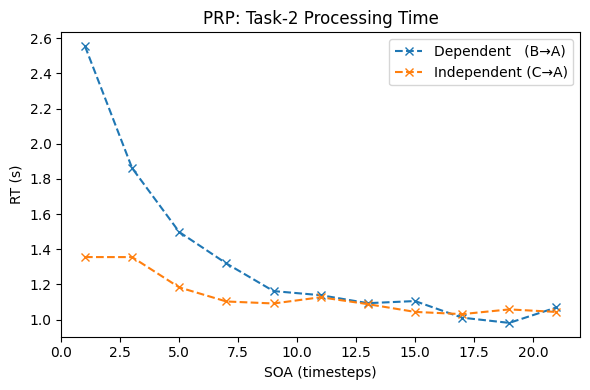

In [5]:
# PRP Simulator. Takes ~1 minute to run with 30 trials per SOA (optim=False).
# ~3 minutes with optim_onset=True

def generate_trial_pair(prp_pair=("B","A"), N_pathways=3, N_features=3, seed=None):
    task_map = {'A': (0,0), 'B': (1,1), 'C': (2,2), 'D': (0,1), 'E': (1,0)}
    rng = np.random.RandomState(seed)

    def sample_single_task(task_name, shared_features=None):
        in_dim, out_dim = task_map[task_name]
        feats = shared_features if shared_features is not None \
                else rng.randint(0, N_features, size=N_pathways)

        stim = np.zeros(N_pathways*N_features, dtype=np.float32)
        for i in range(N_pathways):
            stim[i*N_features + feats[i]] = 1

        cue = np.zeros(N_pathways**2, dtype=np.float32)
        cue[in_dim*N_pathways + out_dim] = 1
        return stim, cue

    # (optional) use the SAME stimulus features for both tasks:
    feats = np.random.randint(0, N_features, size=N_pathways)
    stim1, cue1 = sample_single_task(prp_pair[0], shared_features=feats)
    stim2, cue2 = sample_single_task(prp_pair[1], shared_features=feats)
    return stim1, stim2, cue1, cue2


# ✅ Optional test calls
_ = generate_trial_pair(prp_pair=("B", "A"))
_ = generate_trial_pair(prp_pair=("C", "A"))


# Dependent B→A vs Independent C→A
gen_dep = lambda: generate_trial_pair(("B","A"))
gen_ind = lambda: generate_trial_pair(("C","A"))

# IMPORTANT: compute a single fixed threshold for Task-2=A in single-task mode
# (rename your z_B to z_A if you're using A as Task-2 in both conditions)

results_ba = sweep_soa(wrapper, gen_dep, list(range(1,22,2)),
                       n_trials_per_soa=30, persistence=0.75,
                       dt_lca=0.1, ITI=0.5,
                       z_task2_fixed=z_A,# z_A
                       optimize_onset=True # False
                       )

results_ca = sweep_soa(wrapper, gen_ind, list(range(1,22,2)),
                       n_trials_per_soa=30, persistence=0.75, 
                       dt_lca=0.1, ITI=0.5,
                       z_task2_fixed=z_A, # z_A
                       optimize_onset=True # False
                       )


plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], results_ba["rt_task2_from_stim"], "x--", label="Dependent   (B→A)")
plt.plot(results_ca["soa"], results_ca["rt_task2_from_stim"], "x--", label="Independent (C→A)")
plt.xlabel("SOA (timesteps)"); plt.ylabel("RT (s)")
plt.title("PRP: Task-2 Processing Time")
#plt.savefig("../output/plots/persistence/RT_p075_b02_zb05_nt30_ITI05_sim3init01_SOA1-21-2_OptimOnset.png", dpi=300)
plt.legend(); plt.tight_layout(); plt.show()

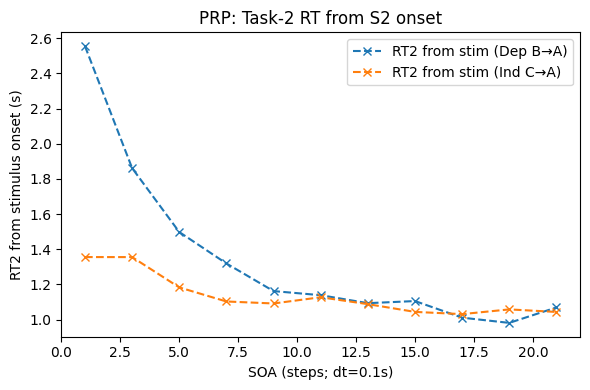

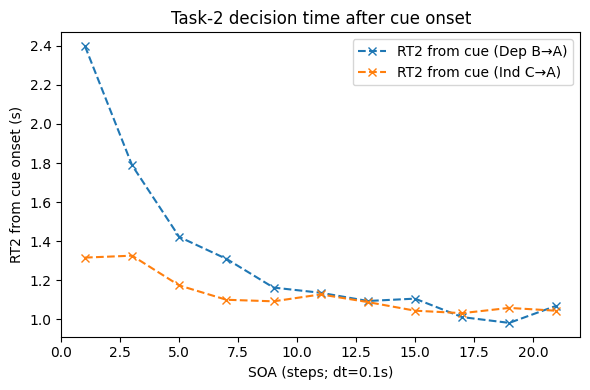

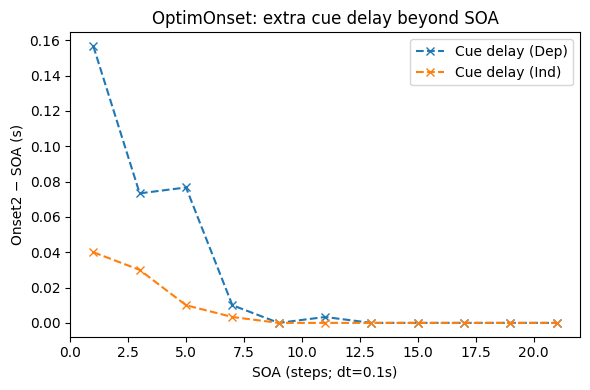

In [6]:
# RT from stimulus onset (SOA)
plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], results_ba["rt_task2_from_stim"], "x--", label="RT2 from stim (Dep B→A)")
plt.plot(results_ca["soa"], results_ca["rt_task2_from_stim"], "x--", label="RT2 from stim (Ind C→A)")
plt.xlabel("SOA (steps; dt=0.1s)")
plt.ylabel("RT2 from stimulus onset (s)")
plt.title("PRP: Task-2 RT from S2 onset")
#plt.savefig("../output/plots/absolute/RT_p09_b02_zb05_nt30_ITI40_sim3init01_SOA5-60_afterfix.png", dpi=300)
plt.legend(); plt.tight_layout(); plt.show()

# RT from Task-2 cue onset
plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], results_ba["rt_task2_tail"], "x--", label="RT2 from cue (Dep B→A)")
plt.plot(results_ca["soa"], results_ca["rt_task2_tail"], "x--", label="RT2 from cue (Ind C→A)")
plt.xlabel("SOA (steps; dt=0.1s)")
plt.ylabel("RT2 from cue onset (s)")
plt.title("Task-2 decision time after cue onset")
plt.legend(); plt.tight_layout(); plt.show()

# What OptimOnset is doing
plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], (np.array(results_ba["onset2"]) - np.array(results_ba["soa"])) * 0.1, "x--", label="Cue delay (Dep)")
plt.plot(results_ca["soa"], (np.array(results_ca["onset2"]) - np.array(results_ca["soa"])) * 0.1, "x--", label="Cue delay (Ind)")
plt.xlabel("SOA (steps; dt=0.1s)")
plt.ylabel("Onset2 − SOA (s)")
plt.title("OptimOnset: extra cue delay beyond SOA")
plt.legend(); plt.tight_layout(); plt.show()




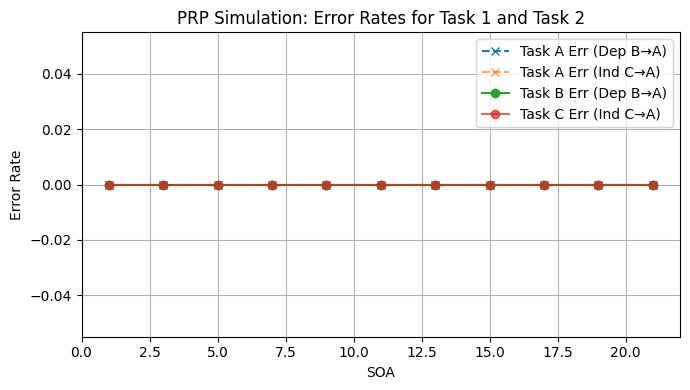

In [7]:
# Error Rates
soa = results_ba["soa"]

# Task-2 (A) error rates
err_A_dep = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_task2"]]
err_A_ind = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_task2"]]

# Task-1 error rates (B for dep, C for ind)
err_T1_dep = [1 - a if not np.isnan(a) else np.nan for a in results_ba["acc_task1"]]  # Task B
err_T1_ind = [1 - a if not np.isnan(a) else np.nan for a in results_ca["acc_task1"]]  # Task C

plt.figure(figsize=(7,4))

# Task 2 (A)
plt.plot(soa, err_A_dep, marker='x', linestyle='--', label="Task A Err (Dep B→A)")
plt.plot(soa, err_A_ind, marker='x', linestyle='--', label="Task A Err (Ind C→A)", alpha=0.7)

# Task 1 (B/C)
plt.plot(soa, err_T1_dep, marker='o', linestyle='-', label="Task B Err (Dep B→A)")
plt.plot(soa, err_T1_ind, marker='o', linestyle='-', label="Task C Err (Ind C→A)", alpha=0.7)

plt.xlabel("SOA")
plt.ylabel("Error Rate")
plt.title("PRP Simulation: Error Rates for Task 1 and Task 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Ensemble

In [9]:
# Utilities: averaging + caching
from pathlib import Path

# ---- Averaging helpers (ignore NaNs) ----
def _nanmean_list(xs):
    arr = np.array(xs, dtype=float)
    return float(np.nanmean(arr)) if arr.size else np.nan

def _average_prp_results(results_list):
    # results_list: list of dicts from sweep_soa
    keys = ("soa", "rt_task1", "acc_task1", "rt_task2", "acc_task2")
    # assume identical SOA grids across nets
    soa = results_list[0]["soa"]
    out = {k: [] for k in keys}
    out["soa"] = soa
    for i in range(len(soa)):
        out["rt_task1"].append(_nanmean_list([r["rt_task1"][i] for r in results_list]))
        out["acc_task1"].append(_nanmean_list([r["acc_task1"][i] for r in results_list]))
        out["rt_task2"].append(_nanmean_list([r["rt_task2"][i] for r in results_list]))
        out["acc_task2"].append(_nanmean_list([r["acc_task2"][i] for r in results_list]))
    return out

# ---- Simple disk cache for model + z ----
def _save_state(wrapper, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    torch.save(wrapper.model.state_dict(), path)

def _load_state(make_wrapper_fn, path):
    wrapper = make_wrapper_fn()
    wrapper.model.load_state_dict(torch.load(path, map_location="cpu"))
    wrapper.model.eval()
    return wrapper

def _save_threshold(z, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump({"z": float(z)}, f)

def _load_threshold(path):
    with open(path, "r") as f:
        return float(json.load(f)["z"])


In [10]:
# 2) Per-network job (train/load, compute z, run PRP)

# You already have these in your codebase:
# - generate_training_set_matlab_style
# - compute_fixed_threshold_for_task_meanargmax
# - sweep_soa
# - generate_trial_pair

def _train_single_network(make_wrapper_fn,
                          train_epochs=5000, stop_loss=1e-3, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    wrapper = make_wrapper_fn()
    X, T, Y, _ = generate_training_set_matlab_style()
    wrapper.train_online(torch.tensor(X), torch.tensor(T), torch.tensor(Y),
                         max_epochs=train_epochs, stop_loss=stop_loss, print_every=200)
    return wrapper

def _per_network_job(net_idx,
                     make_wrapper_fn,
                     store_dir="ensemble_ckpt",
                     train_if_missing=True,
                     train_epochs=5000, stop_loss=1e-3,
                     z_task="A", z_K=27, z_repeats=150,
                     thresholds=np.arange(0.1, 1.5, 0.1),
                     prp_persistence=0.90,
                     prp_trials_per_soa=20,
                     prp_soa=list(range(5,61,5)),
                     dt_lca=0.1, t0=0.15, ITI=0.5,
                     optimize_onset=False):
    """
    Returns:
      dict(
        z=float,
        dep=results_dict,  # sweep_soa(B->A)
        ind=results_dict,  # sweep_soa(C->A)
      )
    """
    os.makedirs(store_dir, exist_ok=True)
    model_path = os.path.join(store_dir, f"net_{net_idx:02d}.pt")
    z_path     = os.path.join(store_dir, f"net_{net_idx:02d}_z_{z_task}.json")

    # 1) Load or train
    if os.path.exists(model_path):
        wrapper = _load_state(make_wrapper_fn, model_path)
    else:
        if not train_if_missing:
            raise FileNotFoundError(f"Missing model {model_path} and training disabled.")
        wrapper = _train_single_network(make_wrapper_fn,
                                        train_epochs=train_epochs,
                                        stop_loss=stop_loss,
                                        seed=net_idx)
        _save_state(wrapper, model_path)

    # 2) Load or compute z for Task-2 (A)
    if os.path.exists(z_path):
        z_A = _load_threshold(z_path)
    else:
        z_A = compute_fixed_threshold_for_task_meanargmax(
            wrapper, task_name=z_task, K=z_K,
            thresholds=thresholds, ITI=ITI, n_repeats=z_repeats,
            persistence=0.0, seed=1000 + net_idx
        )
        _save_threshold(z_A, z_path)

    # 3) PRP runs for Dep (B->A) and Ind (C->A)
    gen_dep = lambda: generate_trial_pair(("B","A"))
    gen_ind = lambda: generate_trial_pair(("C","A"))

    results_ba = sweep_soa(wrapper, gen_dep, prp_soa,
                           n_trials_per_soa=prp_trials_per_soa,
                           persistence=prp_persistence,
                           dt_lca=dt_lca, t0=t0, ITI=ITI,
                           z_task2_fixed=z_A,
                           optimize_onset=optimize_onset)

    results_ca = sweep_soa(wrapper, gen_ind, prp_soa,
                           n_trials_per_soa=prp_trials_per_soa,
                           persistence=prp_persistence,
                           dt_lca=dt_lca, t0=t0, ITI=ITI,
                           z_task2_fixed=z_A,
                           optimize_onset=optimize_onset)

    return {"z": z_A, "dep": results_ba, "ind": results_ca}


In [11]:
# 3) Orchestrator: Run E networks and average

def run_prp_ensemble(E=10,
                     make_wrapper_fn=None,          # <- pass a zero-arg fn that builds your wrapper
                     store_dir="ensemble_ckpt",
                     parallel_workers=0,            # 0 = serial; else use that many processes
                     **kwargs):
    """
    kwargs are forwarded to _per_network_job (e.g., persistence, trials_per_soa, etc.)
    Returns:
      {
        "per_net": [ {"z":..., "dep":..., "ind":...}, ... ],
        "avg":     { "dep": avg_dict, "ind": avg_dict },
        "z_list":  [z1, z2, ...]
      }
    """
    jobs = []
    if parallel_workers and parallel_workers > 0:
        import multiprocessing as mp
        with mp.Pool(processes=parallel_workers) as pool:
            for i in range(E):
                jobs.append(pool.apply_async(_per_network_job, (i, make_wrapper_fn, store_dir), kwargs))
            per_net = [j.get() for j in jobs]
    else:
        per_net = []
        for i in range(E):
            per_net.append(_per_network_job(i, make_wrapper_fn, store_dir, **kwargs))

    dep_avg = _average_prp_results([d["dep"] for d in per_net])
    ind_avg = _average_prp_results([d["ind"] for d in per_net])

    return {"per_net": per_net, "avg": {"dep": dep_avg, "ind": ind_avg},
            "z_list": [d["z"] for d in per_net]}


In [12]:
#helper
# PRP Simulator. Takes ~1 minute to run with 30 trials per SOA (optim=False).
# ~3 minutes with optim_onset=True

def generate_trial_pair(prp_pair=("B","A"), N_pathways=3, N_features=3, seed=None):
    task_map = {'A': (0,0), 'B': (1,1), 'C': (2,2), 'D': (0,1), 'E': (1,0)}
    rng = np.random.RandomState(seed)

    def sample_single_task(task_name, shared_features=None):
        in_dim, out_dim = task_map[task_name]
        feats = shared_features if shared_features is not None \
                else rng.randint(0, N_features, size=N_pathways)

        stim = np.zeros(N_pathways*N_features, dtype=np.float32)
        for i in range(N_pathways):
            stim[i*N_features + feats[i]] = 1

        cue = np.zeros(N_pathways**2, dtype=np.float32)
        cue[in_dim*N_pathways + out_dim] = 1
        return stim, cue

    # (optional) use the SAME stimulus features for both tasks:
    feats = np.random.randint(0, N_features, size=N_pathways)
    stim1, cue1 = sample_single_task(prp_pair[0], shared_features=feats)
    stim2, cue2 = sample_single_task(prp_pair[1], shared_features=feats)
    return stim1, stim2, cue1, cue2


# ✅ Optional test calls
_ = generate_trial_pair(prp_pair=("B", "A"))
_ = generate_trial_pair(prp_pair=("C", "A"))


# Dependent B→A vs Independent C→A
gen_dep = lambda: generate_trial_pair(("B","A"))
gen_ind = lambda: generate_trial_pair(("C","A"))

z_A per net: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


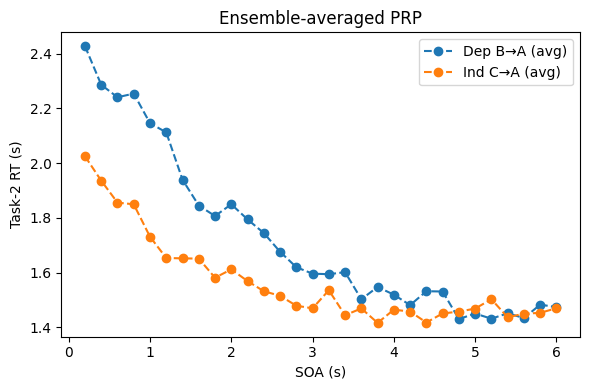

In [19]:
# 4. Example Usage

# A factory that constructs an *uninitialized* wrapper (so each net trains independently)
def make_wrapper_fn():
    # e.g., TaskNetworkWrapper(...) as used in your project
    # fill with your actual constructor args:
    return TaskNetworkWrapper(
    stim_input_dim = 3*3,
    task_input_dim = 3**2,
    hidden_dim     = 100,
    output_dim     = 3*3,
    learning_rate  = 0.3,
    # Sim-3 init/bias/decay:
    init_scale=0.1,
    init_task_scale=None,   # → 0.1, same as MATLAB for Sim-3
    bias_offset=-2.0,
    default_weight_decay=0.0,  # Sim-3 uses no L2
    device="cpu",
)

ensemble_out = run_prp_ensemble(
    E=10,
    make_wrapper_fn=make_wrapper_fn,
    store_dir="ensemble_ckpt_p09",
    parallel_workers=6,           # set <= your CPU cores; 0 for serial
    train_if_missing=True,
    train_epochs=5000, stop_loss=1e-3,
    z_task="A", z_K=27, z_repeats=100,
    thresholds=np.arange(0.1, 1.5, 0.1),
    prp_persistence=0.90,
    prp_trials_per_soa=30,        # keep modest for speed
    prp_soa=list(range(2,61,2)),
    dt_lca=0.1, t0=0.15, ITI=4.0,
    optimize_onset=True          # cheaper first pass
)

print("z_A per net:", np.round(ensemble_out["z_list"], 3))
dt = 0.1

# Plot ensemble-mean Task-2 RT (absolute) if you like:
avg_dep = ensemble_out["avg"]["dep"]
avg_ind = ensemble_out["avg"]["ind"]
# this part is mine
rt2_tail_dep = [rt - soa*dt for rt, soa in zip(avg_dep["rt_task2"], avg_dep["soa"])]
rt2_tail_ind = [rt - soa*dt for rt, soa in zip(avg_ind["rt_task2"], avg_ind["soa"])]

plt.figure(figsize=(6,4))
plt.plot(np.array(avg_dep["soa"])*dt, rt2_tail_dep, "o--", label="Dep B→A (avg)")
plt.plot(np.array(avg_ind["soa"])*dt, rt2_tail_ind, "o--", label="Ind C→A (avg)")
plt.xlabel("SOA (s)"); plt.ylabel("Task-2 RT (s)")
plt.title("Ensemble-averaged PRP")
plt.savefig("../output/plots/ensemble/RT_p09_zb05_nt30_ITI40_SOA2-60_E10_OptimOnset.png", dpi=300)
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
dt = 0.1  # your dt_lca
rt2_tail_dep = [rt - soa*dt for rt, soa in zip(results_ba["rt_task2"], results_ba["soa"])]
rt2_tail_ind = [rt - soa*dt for rt, soa in zip(results_ca["rt_task2"], results_ca["soa"])]

plt.figure(figsize=(6,4))
plt.plot(results_ba["soa"], rt2_tail_dep, "x--", label="Task 2 tail RT (Dep B→A)")
plt.plot(results_ca["soa"], rt2_tail_ind, "x--", label="Task 2 tail RT (Ind C→A)")
plt.xlabel("SOA (1-8s)"); plt.ylabel("Tail RT (s)")
plt.title("PRP: Task-2 Processing Time")
#plt.savefig("../output/plots/absolute/RT_p09_zb05_nt30_ITI05_sim3init01_SOA5-60_OptimOnset.png", dpi=300)
plt.legend(); plt.tight_layout(); plt.show()